## **01. Exploration & EDA — Conversion Rate Challenge**

**Objectif** : comprendre la structure du dataset, identifier les variables clés, poser les bases du preprocessing.

**Métrique de compétition** : F1-score

**Plan du notebook** :
1. Chargement & qualité des données
2. Distribution des features
3. Taux de conversion par segment
4. Corrélations
5. Conclusions & insights

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

SEED = 42
conversion_data_train_path = '../data/conversion_data_train.csv'
conversion_data_test_path = '../data/conversion_data_test.csv'
output_image_path = '../outputs/images/'

### **1. Chargement & qualité des données**

In [4]:
df = pd.read_csv(conversion_data_train_path)
print(f'Shape : {df.shape}')
df.head()

Shape : (284580, 6)


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [5]:
# Types, valeurs manquantes
print('Types & Valeurs manquantes')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2)
})
display(info)

Types & Valeurs manquantes


,dtype,non_null,null,null_%
country,str,284580,0,0.0
age,int64,284580,0,0.0
new_user,int64,284580,0,0.0
source,str,284580,0,0.0
total_pages_visited,int64,284580,0,0.0
converted,int64,284580,0,0.0


In [6]:
# Doublons
n_dup = df.duplicated().sum()
print(f'Lignes dupliquées : {n_dup} ({n_dup/len(df)*100:.1f}% du dataset)')
print()

Lignes dupliquées : 268769 (94.4% du dataset)



In [7]:
# Statistiques descriptives
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,284580,4,US,160124,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,284580.0,NaN,NaN,NaN,30.564203,8.266789,17.0,24.0,30.0,36.0,123.0
new_user,284580.0,NaN,NaN,NaN,0.685452,0.464336,0.0,0.0,1.0,1.0,1.0
source,284580,3,Seo,139477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_pages_visited,284580.0,NaN,NaN,NaN,4.873252,3.341995,1.0,2.0,4.0,7.0,29.0
converted,284580.0,NaN,NaN,NaN,0.032258,0.176685,0.0,0.0,0.0,0.0,1.0


In [8]:
# Outliers sur l'âge
print("Valeurs d'âge > 79 ans :")
print(df[df['age'] > 79]['age'].value_counts())
print()
print(f"Médiane d'âge globale : {df['age'].median()}")
# TODO: 2 outliers aberrants (111, 123 ans) — seront remplacés par la médiane au preprocessing

Valeurs d'âge > 79 ans :
age
111    1
123    1
Name: count, dtype: int64

Médiane d'âge globale : 30.0


### **2. Distribution des features**

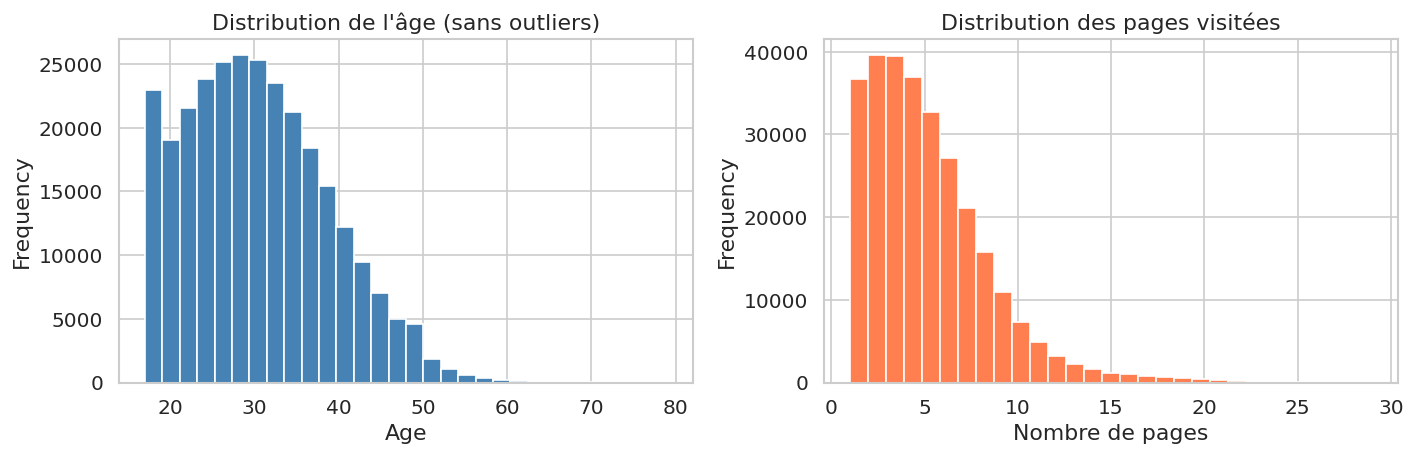

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution âge
df[df['age'] <= 79]['age'].plot.hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de l\'âge (sans outliers)')
axes[0].set_xlabel('Age')

# Distribution pages visitées
df['total_pages_visited'].plot.hist(bins=29, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Distribution des pages visitées')
axes[1].set_xlabel('Nombre de pages')

plt.tight_layout()
plt.savefig(f'{output_image_path}/01_distributions_numeriques.png', bbox_inches='tight')
plt.show()

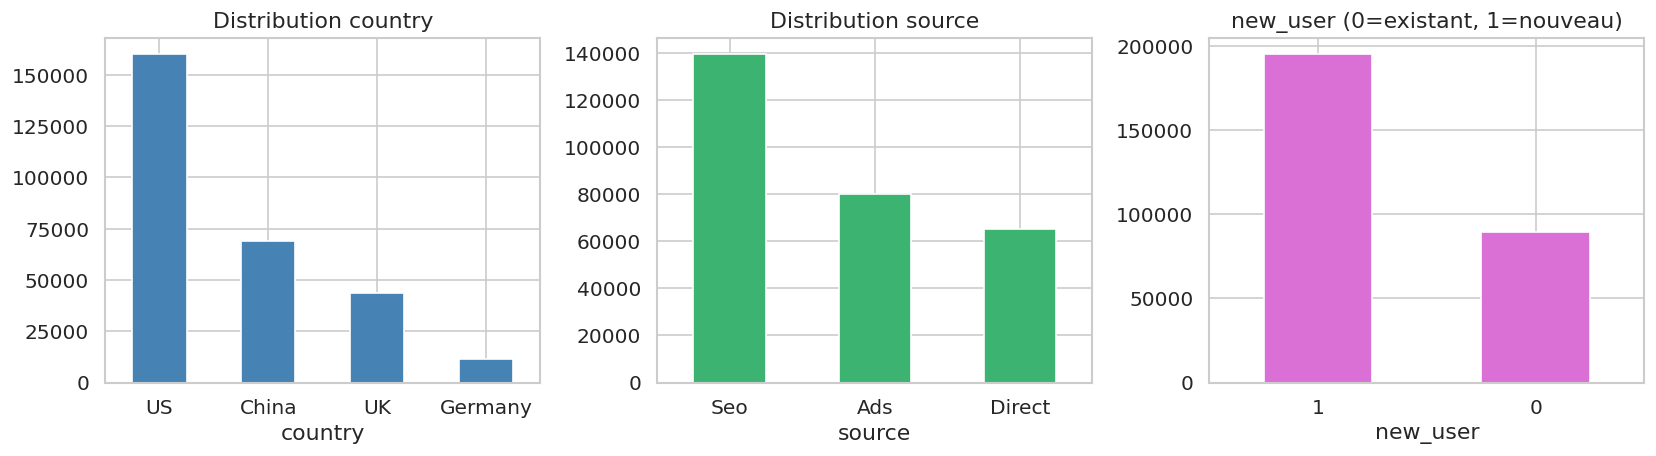

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Country
df['country'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution country')
axes[0].tick_params(axis='x', rotation=0)

# Source
df['source'].value_counts().plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribution source')
axes[1].tick_params(axis='x', rotation=0)

# new_user
df['new_user'].value_counts().plot.bar(ax=axes[2], color='orchid', edgecolor='white')
axes[2].set_title('new_user (0=existant, 1=nouveau)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{output_image_path}/02_distributions_categoriques.png', bbox_inches='tight')
plt.show()

### **3. Analyse de la variable cible**

In [14]:
# Déséquilibre de classe
conversion_counts = df['converted'].value_counts()
conversion_rate = df['converted'].mean()

print(f'Non convertis : {conversion_counts[0]:,} ({100-conversion_rate*100:.2f}%)')
print(f'Convertis     : {conversion_counts[1]:,} ({conversion_rate*100:.2f}%)')
print(f'Ratio négatif/positif : {conversion_counts[0]/conversion_counts[1]:.0f}:1')
print()
print('Fort déséquilibre => utiliser class_weight ou scale_pos_weight')
print("Métrique : F1-score, PAS l'accuracy")

Non convertis : 275,400 (96.77%)
Convertis     : 9,180 (3.23%)
Ratio négatif/positif : 30:1

Fort déséquilibre => utiliser class_weight ou scale_pos_weight
Métrique : F1-score, PAS l'accuracy


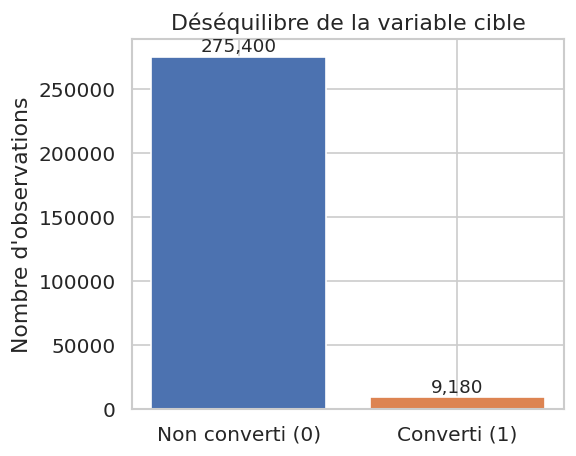

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Non converti (0)', 'Converti (1)'],
              conversion_counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white')
for bar, val in zip(bars, conversion_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Déséquilibre de la variable cible')
ax.set_ylabel('Nombre d\'observations')
plt.tight_layout()
plt.savefig(f'{output_image_path}/03_desequilibre_cible.png', bbox_inches='tight')
plt.show()

### **4. Taux de conversion par segment**

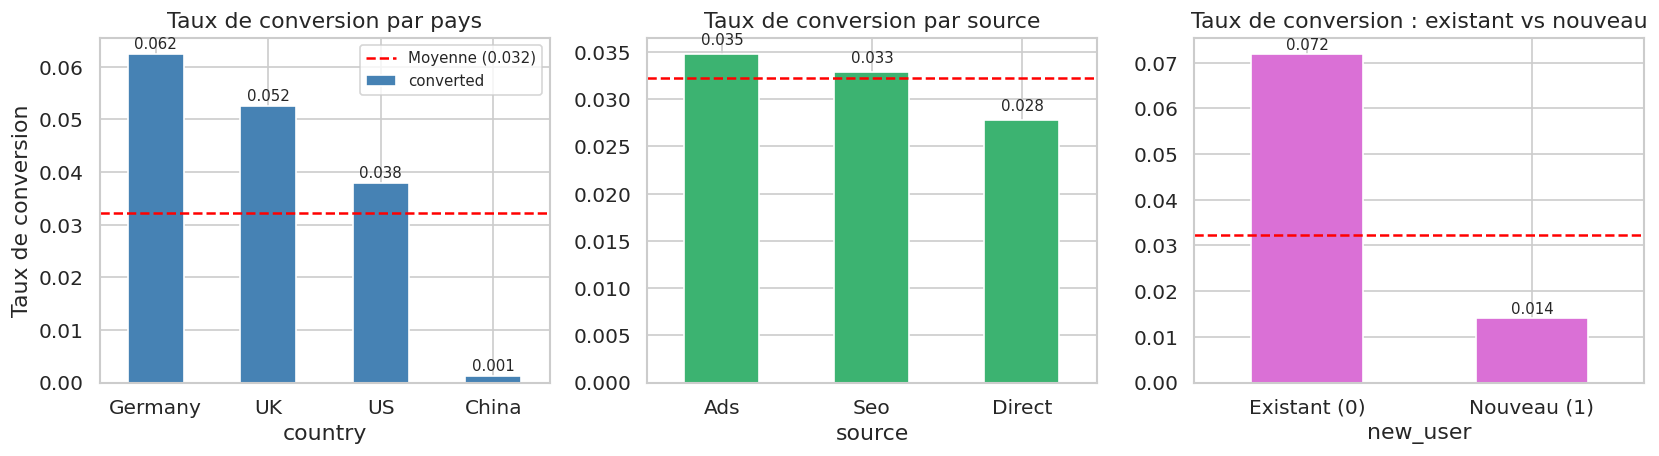

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Par country
conv_country = df.groupby('country')['converted'].mean().sort_values(ascending=False)
conv_country.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Taux de conversion par pays')
axes[0].set_ylabel('Taux de conversion')
axes[0].axhline(conversion_rate, color='red', linestyle='--', label=f'Moyenne ({conversion_rate:.3f})')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(conv_country):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# Par source
conv_source = df.groupby('source')['converted'].mean().sort_values(ascending=False)
conv_source.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Taux de conversion par source')
axes[1].axhline(conversion_rate, color='red', linestyle='--')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(conv_source):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# Par new_user
conv_user = df.groupby('new_user')['converted'].mean()
conv_user.plot.bar(ax=axes[2], color='orchid', edgecolor='white')
axes[2].set_title('Taux de conversion : existant vs nouveau')
axes[2].axhline(conversion_rate, color='red', linestyle='--')
axes[2].tick_params(axis='x', rotation=0)
axes[2].set_xticklabels(['Existant (0)', 'Nouveau (1)'], rotation=0)
for i, v in enumerate(conv_user):
    axes[2].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{output_image_path}/04_conversion_par_segment.png', bbox_inches='tight')
plt.show()

In [17]:
# Insight principal : total_pages_visited vs conversion
df['pages_bucket'] = pd.cut(
    df['total_pages_visited'],
    bins=[0, 3, 6, 10, 15, 29],
    labels=['1-3', '4-6', '7-10', '11-15', '16+']
)

conv_pages = df.groupby('pages_bucket', observed=True)['converted'].agg(['mean', 'sum', 'count'])
conv_pages.columns = ['taux_conversion', 'nb_convertis', 'nb_total']
conv_pages['taux_conversion_pct'] = (conv_pages['taux_conversion'] * 100).round(2)
display(conv_pages)

,taux_conversion,nb_convertis,nb_total,taux_conversion_pct
pages_bucket,,,,
1-3,0.000173,20,115648,0.02
4-6,0.001798,174,96770,0.18
7-10,0.021500,1186,55164,2.15
11-15,0.313757,4103,13077,31.38
16+,0.942872,3697,3921,94.29


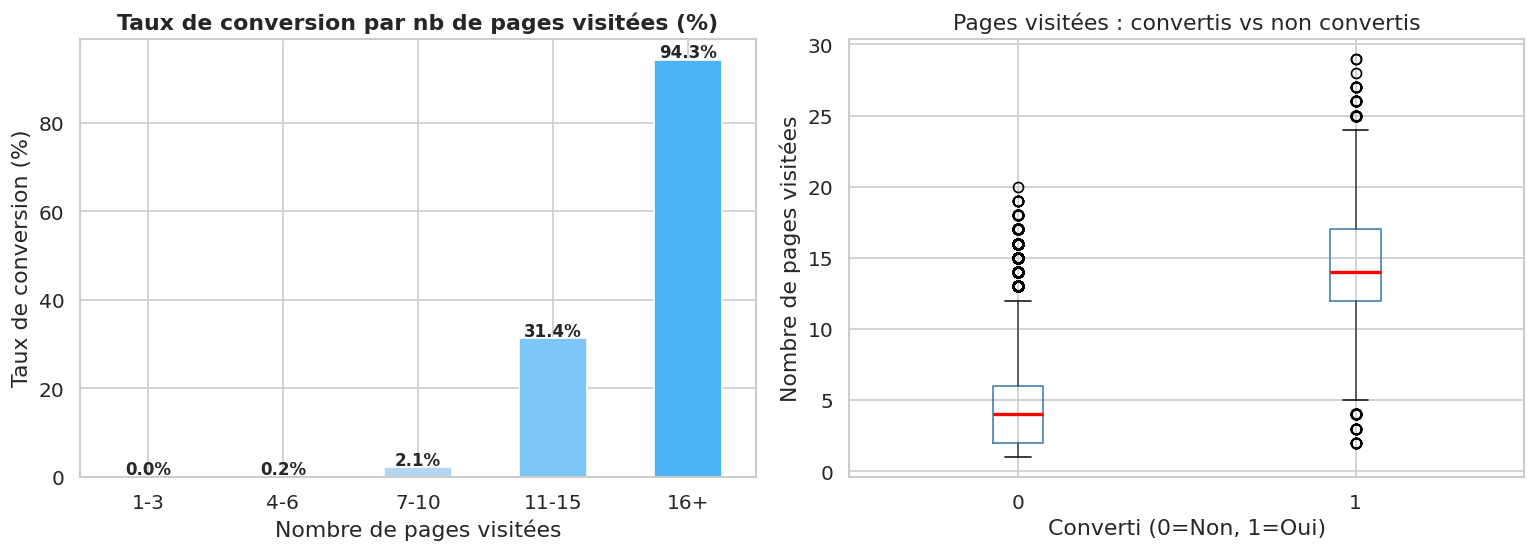

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Taux de conversion par bucket de pages
colors = ['#eaf3fb', '#d4e6f1', '#b3d7f2', '#7fc6f8', '#4ab3f4']
conv_pages['taux_conversion_pct'].plot.bar(ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Taux de conversion par nb de pages visitées (%)', fontweight='bold')
axes[0].set_ylabel('Taux de conversion (%)')
axes[0].set_xlabel('Nombre de pages visitées')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(conv_pages['taux_conversion_pct']):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Distribution de pages visitées par groupe converted
df.boxplot(column='total_pages_visited', by='converted', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Pages visitées : convertis vs non convertis')
axes[1].set_xlabel('Converti (0=Non, 1=Oui)')
axes[1].set_ylabel('Nombre de pages visitées')
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{output_image_path}/05_pages_vs_conversion.png', bbox_inches='tight')
plt.show()

In [20]:
# Age moyen : convertis vs non convertis
age_stats = df.groupby('converted')['age'].describe()
display(age_stats)
print()
print(f'Age moyen non-convertis : {df[df["converted"]==0]["age"].mean():.1f} ans')
print(f'Age moyen convertis     : {df[df["converted"]==1]["age"].mean():.1f} ans')
print('=> Les convertis sont légèrement plus jeunes (26.6 vs 30.7 ans)')

,count,mean,std,min,25%,50%,75%,max
converted,,,,,,,,
0,275400.0,30.697422,8.27009,17.0,24.0,30.0,36.0,79.0
1,9180.0,26.567647,7.08539,17.0,21.0,25.0,31.0,123.0



Age moyen non-convertis : 30.7 ans
Age moyen convertis     : 26.6 ans
=> Les convertis sont légèrement plus jeunes (26.6 vs 30.7 ans)


/tmp/ipykernel_966333/948418273.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['converted'] == 0][df['age'] <= 79]['age'].plot.hist(
/tmp/ipykernel_966333/948418273.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['converted'] == 1][df['age'] <= 79]['age'].plot.hist(


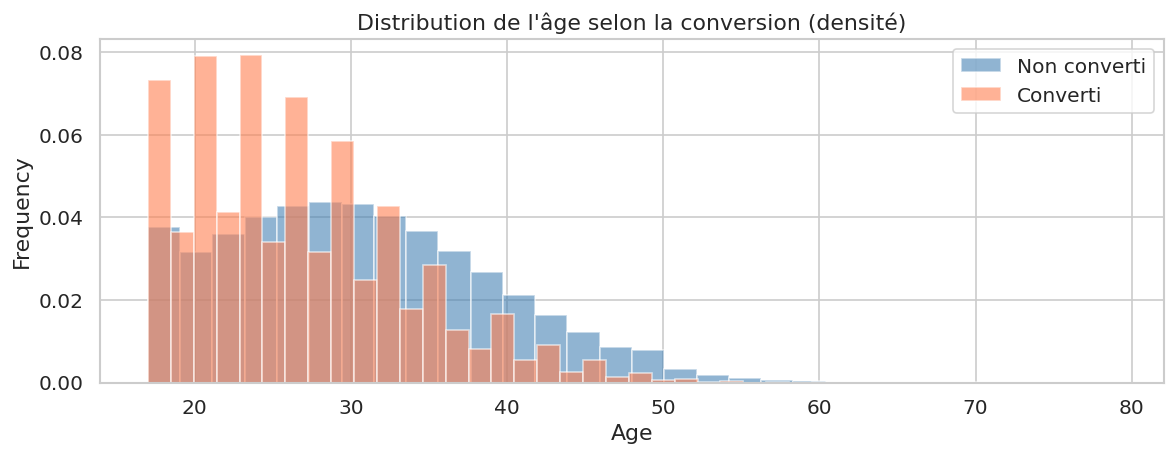

In [ ]:
# Distribution de l'âge par statut de conversion
fig, ax = plt.subplots(figsize=(10, 4))
df[df['converted'] == 0][df['age'] <= 79]['age'].plot.hist(
    bins=30, alpha=0.6, label='Non converti', color='steelblue', ax=ax, density=True)

df[df['converted'] == 1][df['age'] <= 79]['age'].plot.hist(
    bins=30, alpha=0.6, label='Converti', color='coral', ax=ax, density=True)
    
ax.set_title('Distribution de l\'âge selon la conversion (densité)')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.savefig(f'{output_image_path}/06_age_vs_conversion.png', bbox_inches='tight')
plt.show()

### **5. Matrice de corrélation**

In [22]:
# Corrélations numériques avec la cible
corr_with_target = df.corr(numeric_only=True)['converted'].drop('converted').sort_values(ascending=False)
print("Corrélations avec converted")
print(corr_with_target.round(4))

Corrélations avec converted
total_pages_visited    0.5292
age                   -0.0883
new_user              -0.1521
Name: converted, dtype: float64


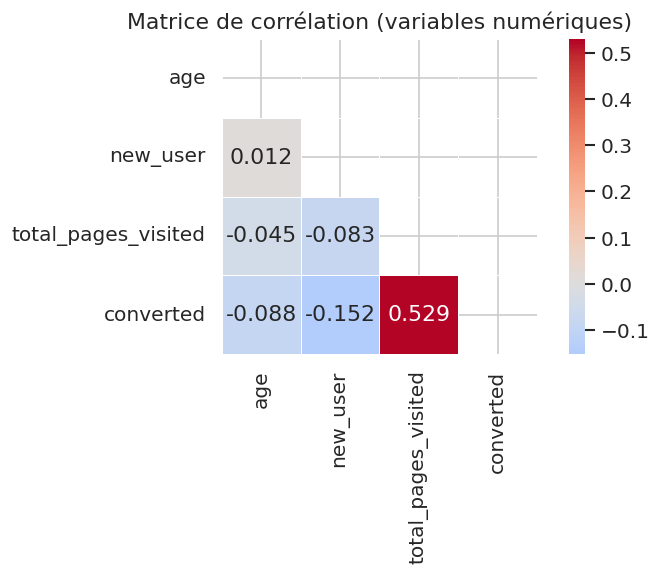

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
numeric_df = df[['age', 'new_user', 'total_pages_visited', 'converted']]
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
    center=0, square=True, linewidths=0.5,
    mask=mask, ax=ax
)
ax.set_title('Matrice de corrélation (variables numériques)')
plt.tight_layout()
plt.savefig(f'{output_image_path}/07_correlation_matrix.png', bbox_inches='tight')
plt.show()

### **6. Analyse bivarié : interactions entre variables**

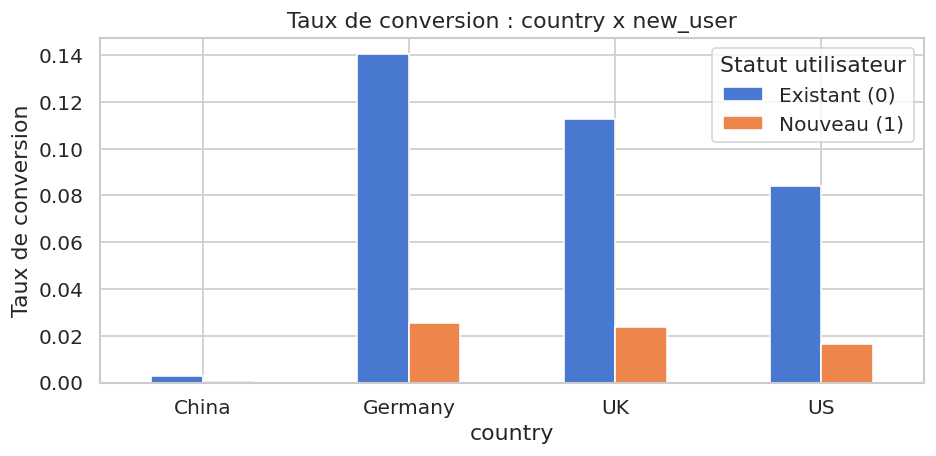

new_user,Existant (0),Nouveau (1)
country,,
China,0.0027,0.0007
Germany,0.1405,0.0254
UK,0.1128,0.0239
US,0.0839,0.0165


In [24]:
# Taux de conversion : country × new_user
pivot = df.pivot_table(
    values='converted',
    index='country',
    columns='new_user',
    aggfunc='mean'
).rename(columns={0: 'Existant (0)', 1: 'Nouveau (1)'})

fig, ax = plt.subplots(figsize=(8, 4))

pivot.plot.bar(ax=ax, edgecolor='white')
ax.set_title('Taux de conversion : country x new_user')
ax.set_ylabel('Taux de conversion')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Statut utilisateur')

plt.tight_layout()
plt.savefig(f'{output_image_path}/08_country_x_newuser.png', bbox_inches='tight')
plt.show()

display(pivot.round(4))

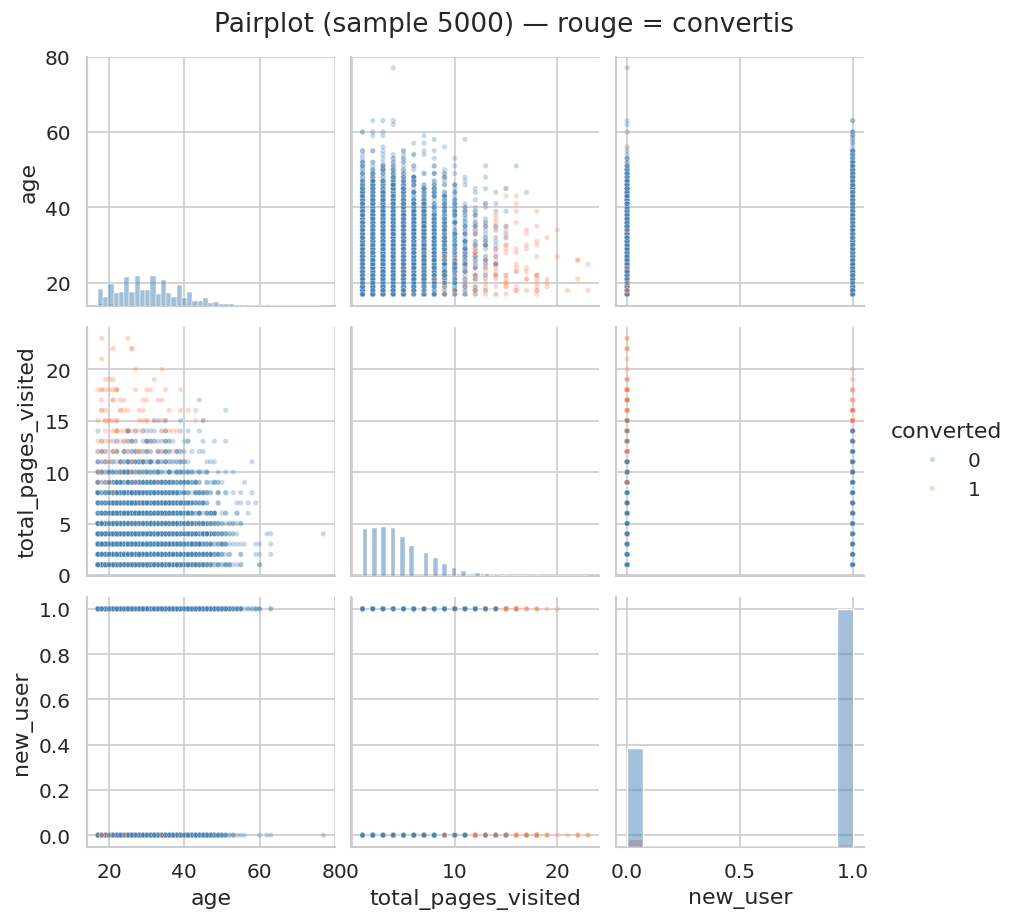

In [25]:
# Pairplot rapide (sur un sample)
sample = df[df['age'] <= 79].sample(5000, random_state=SEED)
g = sns.pairplot(
    sample[['age', 'total_pages_visited', 'new_user', 'converted']],
    hue='converted',
    diag_kind='hist',
    plot_kws={'alpha': 0.3, 's': 10},
    palette={0: 'steelblue', 1: 'coral'}
)
g.fig.suptitle('Pairplot (sample 5000) — rouge = convertis', y=1.02)
plt.savefig(f'{output_image_path}/09_pairplot.png', bbox_inches='tight')
plt.show()

### **7. Synthèse des insights EDA**

- `total_pages_visited` est de loin le meilleur prédicteur (corr=0.53). Les visiteurs ayant vu 16+ pages convertissent à **94%** contre 0.02% pour 1-3 pages.   
*Action preprocessing :* Garder tel quel, envisager une feature `high_engagement` (pages > 10)

- Les **utilisateurs existants** (new_user=0) convertissent à 7.2% contre 1.4% pour les nouveaux.   
*Action preprocessing :* Feature déjà binaire, créer `is_returning` pour lisibilité 

- La **Chine** ne convertit presque pas (0.13%) — comportement radicalement différent des autres pays.  
*Action preprocessing :* Créer un flag `is_china` — potentielle barrière linguistique ou culturelle

- Les **convertis sont plus jeunes** (26.6 vs 30.7 ans en moyenne).  
*Action preprocessing :* StandardScaler sur l'âge, clip des outliers > 79 ans

- **94% de doublons** dans le dataset (logs web normaux).  
*Action preprocessing :* Conserver les doublons (reflètent la vraie distribution du trafic)

- **Déséquilibre fort** : 3.23% de positifs (ratio ~30:1).   
*Action preprocessing :* `scale_pos_weight=30` (XGBoost) ou `class_weight='balanced'`

- La **source** (Ads/Seo/Direct) a très peu d'impact (différence < 1%).  
*Action preprocessing :* Encoder mais faible importance attendue